In [1]:
!pip install easyocr

In [2]:
!pip install facenet_pytorch

In [4]:
import easyocr
import cv2
import re
import matplotlib.pyplot as plt


img_path = 'id sample.png'
image = cv2.imread(img_path)
image_rgb = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)


#**ID number exctraction**



In [5]:
reader = easyocr.Reader(['ar', 'en'])


results = reader.readtext(image_rgb)


pattern = re.compile(r'\d{10}[ء-ي]')


id_number = None
for bbox, text, conf in results:
    if conf > 0.5:
        clean_text = text.replace(" ", "")
        match = pattern.search(clean_text)

        if match:
            id_number = match.group()
            break


if id_number:
    print("Extracted Jordanian ID Number:", id_number)
else:
    print("Jordanian ID Number not found.")


Progress: |██████████████████████████████████████████████████| 100.0% Complete

Progress: |██████████████████████████████████████████████████| 100.0% CompleteJordanian ID Number not found.


### **Face Extraction**

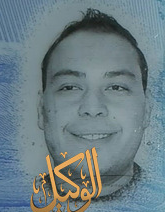

In [6]:
from google.colab.patches import cv2_imshow
import cv2
import matplotlib.pyplot as plt


img_path = 'id sample.png'
image = cv2.imread(img_path)


height, width, _ = image.shape


face_roi = image[int(height * 0.36):int(height * 0.95),
                 int(width * 0.05):int(width * 0.35)]

cv2_imshow(face_roi)

## **Pipeline to match the face and add ID to a DF**

Jordanian ID Number not found.


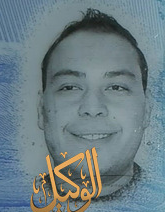

FileNotFoundError: [Errno 2] No such file or directory: 'image.png'

In [1]:
import os
import re
import csv
import cv2
import numpy as np
from PIL import Image
import torch
import easyocr
from google.colab.patches import cv2_imshow
from facenet_pytorch import MTCNN, InceptionResnetV1


device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

reader = easyocr.Reader(['ar', 'en'])
mtcnn = MTCNN(keep_all=True, device=device)
resnet = InceptionResnetV1(pretrained="vggface2").eval().to(device)

#load your images here
id_image_path = 'id sample.png'
other_face_path = 'image.png'  # image to verify against
extracted_face_path = 'extracted_face.png'
database_csv = 'verified_ids.csv'


def normalize_embedding(embedding):
    norm = np.linalg.norm(embedding)
    return embedding if norm == 0 else embedding / norm

def extract_faces_and_embeddings(image_path):
    img = Image.open(image_path).convert("RGB")
    face_crops = mtcnn(img)
    if face_crops is None or len(face_crops) == 0:
        return None
    face_crop = face_crops[0].unsqueeze(0).to(device)
    embedding = resnet(face_crop).detach().cpu().numpy()
    return embedding

def compare_faces(id_image_path, other_image_path, threshold=0.6):
    id_embedding = extract_faces_and_embeddings(id_image_path)
    other_embedding = extract_faces_and_embeddings(other_image_path)
    if id_embedding is None or other_embedding is None:
        print("Could not detect face in one of the images.")
        return False
    id_embedding = normalize_embedding(id_embedding.flatten())
    other_embedding = normalize_embedding(other_embedding.flatten())
    similarity = np.dot(id_embedding, other_embedding)
    print(f"Cosine similarity: {similarity:.4f}")
    return similarity >= threshold

def add_to_database(id_number, path='database_csv'):

    if not os.path.isfile(path):
        with open(path, 'w', newline='') as f:
            writer = csv.writer(f)
            writer.writerow(['ID Number'])


    with open(path, 'r') as f:
        reader = csv.reader(f)
        next(reader)
        for row in reader:
            if row and row[0] == id_number:
                print(f"ID number {id_number} already stored.")
                return


    with open(path, 'a', newline='') as f:
        writer = csv.writer(f)
        writer.writerow([id_number])
    print(f"ID number {id_number} added to database.")


image = cv2.imread(id_image_path)
if image is None:
    raise FileNotFoundError(f"Could not load image at: {id_image_path}")

image_rgb = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)
results = reader.readtext(image_rgb)


pattern = re.compile(r'\d{10}[ء-ي]')
id_number = None
for bbox, text, conf in results:
    if conf > 0.5:
        clean_text = text.replace(" ", "")
        match = pattern.search(clean_text)
        if match:
            id_number = match.group()
            break

if id_number:
    print("Extracted Jordanian ID Number:", id_number)
else:
    print("Jordanian ID Number not found.")
    exit()

height, width, _ = image.shape
face_roi = image[int(height * 0.36):int(height * 0.95), int(width * 0.05):int(width * 0.35)]
cv2.imwrite(extracted_face_path, face_roi)
cv2_imshow(face_roi)


if compare_faces(extracted_face_path, other_face_path):
    print("Same person")
    add_to_database(id_number)
else:
    print("Different person. ID not added.")


In [ ]:
import pandas as pd

database_csv = 'verified_ids.csv'

df = pd.read_csv(database_csv)
print("Verified ID Database:")
print(df)


Testing

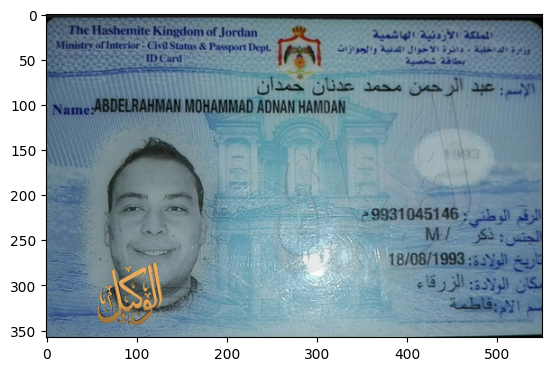

In [41]:
import matplotlib.pyplot as plt
import cv2

image = cv2.imread('sample 22.png')
img = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)
plt.imshow(img)

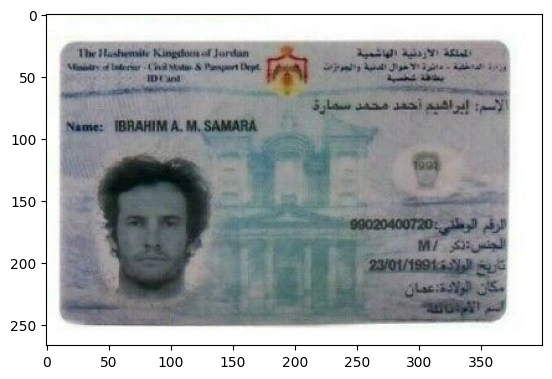

In [43]:
import matplotlib.pyplot as plt
import cv2

image = cv2.imread('sample 24.jpg')
img = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)
plt.imshow(img)

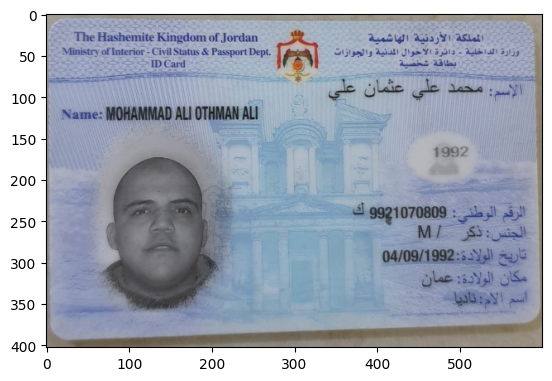

In [54]:
import matplotlib.pyplot as plt
import cv2

image = cv2.imread('sample 25.jpg')
img = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)
plt.imshow(img)

In [55]:
def face(img):
  from google.colab.patches import cv2_imshow
  import cv2
  import matplotlib.pyplot as plt


  img_path = img
  image = cv2.imread(img_path)


  height, width, _ = image.shape


  face_roi = image[int(height * 0.36):int(height * 0.95),
                  int(width * 0.05):int(width * 0.35)]

  cv2_imshow(face_roi)

🧾 Extracted Name: M٥HAMMAD ALI 0THIAI ALI
🆔 Extracted Jordanian National ID: 9921070809
📅 Extracted Date of Birth: 04/09/1992


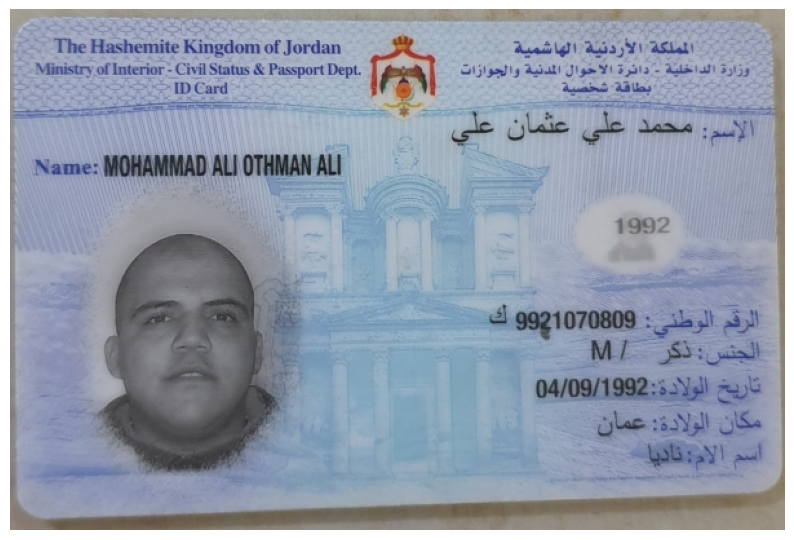

In [58]:
import easyocr
import cv2
import re
import matplotlib.pyplot as plt

image_rgb = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)


reader = easyocr.Reader(['ar', 'en'])
results = reader.readtext(image_rgb)

id_pattern = re.compile(r'\d{10}')
dob_pattern = re.compile(r'\b\d{1,2}/\d{1,2}/\d{4}\b')
name_keywords = ['name', 'الاسم']
dob_keywords = ['birth', 'الولادة']

id_number = None
full_name = None
dob = None

for i, (bbox, text, conf) in enumerate(results):
    if conf < 0.5:
        continue

    lower_text = text.lower().strip()

    if any(key in lower_text for key in name_keywords):
        if i + 1 < len(results):
            full_name = results[i + 1][1].strip()

    clean_text = text.replace(" ", "")
    match = id_pattern.search(clean_text)
    if match:
        id_number = match.group()

    dob_match = dob_pattern.search(text)
    if dob_match and not dob:
        dob = dob_match.group()

if full_name:
    print("🧾 Extracted Name:", full_name)
else:
    print("❌ Name not found.")

if id_number:
    print("🆔 Extracted Jordanian National ID:", id_number)
else:
    print("❌ Jordanian National ID not found.")

if dob:
    print("📅 Extracted Date of Birth:", dob)
else:
    print("❌ Date of Birth not found.")

plt.figure(figsize=(10, 10))
plt.imshow(image_rgb)
plt.axis('off')
plt.show()